Задача 6. Обучение без учителя

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка точности вывода
%precision %.4f
%matplotlib inline

In [41]:
dataset = pd.read_csv('mnist.csv', on_bad_lines='skip')

In [42]:
dataset.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
dataset['label'].value_counts()

label
1    1135
2    1032
7    1028
3    1010
9    1009
4     982
0     980
8     974
6     958
5     892
Name: count, dtype: int64

In [44]:
true_labels = dataset['label']
data = dataset.drop(columns='label')

In [45]:
%%time
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
pca_data = pca.fit_transform(data)

CPU times: user 1.45 s, sys: 12.9 ms, total: 1.46 s
Wall time: 185 ms


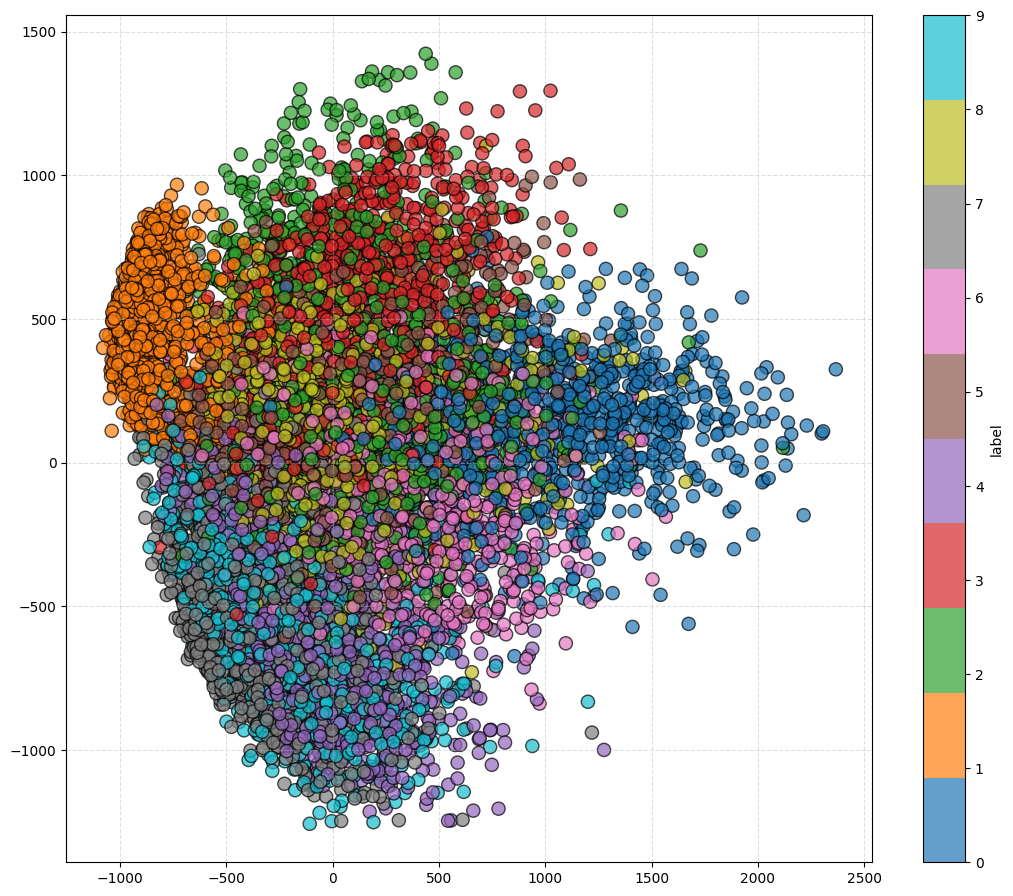

In [46]:
plt.figure(figsize=(13, 11))
plt.scatter(pca_data[:, 0], pca_data[:, 1],
            c=true_labels, edgecolors='k', alpha=0.7, s=90, cmap='tab10')
plt.colorbar(label='label')
plt.grid(True, linestyle='dashed', alpha=0.4)
plt.show()

In [47]:
%%time
from sklearn.manifold import TSNE

tsne_model = TSNE(random_state=42)
tsne_data = tsne_model.fit_transform(data)

CPU times: user 2min 27s, sys: 83.4 ms, total: 2min 27s
Wall time: 25.1 s


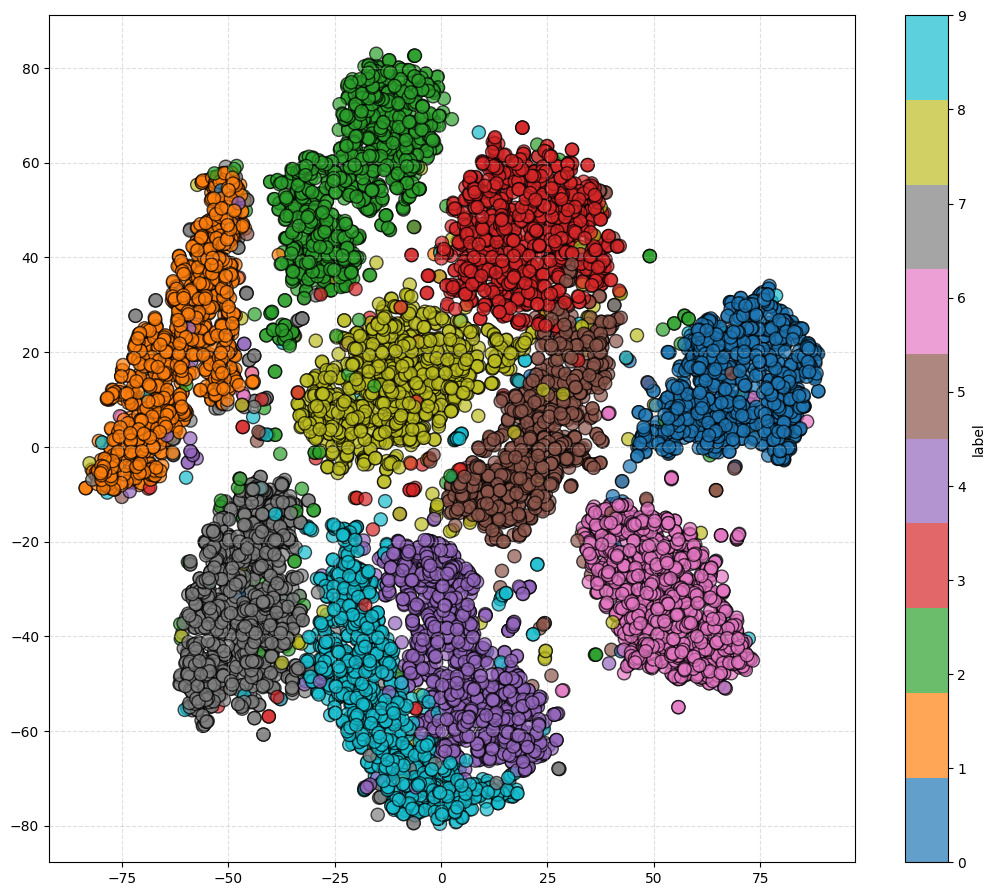

In [48]:
plt.figure(figsize=(13, 11))
plt.scatter(tsne_data[:, 0], tsne_data[:, 1],
            c=true_labels, edgecolors='k', alpha=0.7, s=90, cmap='tab10')
plt.colorbar(label='label')
plt.grid(True, linestyle='dashed', alpha=0.4)
plt.show()

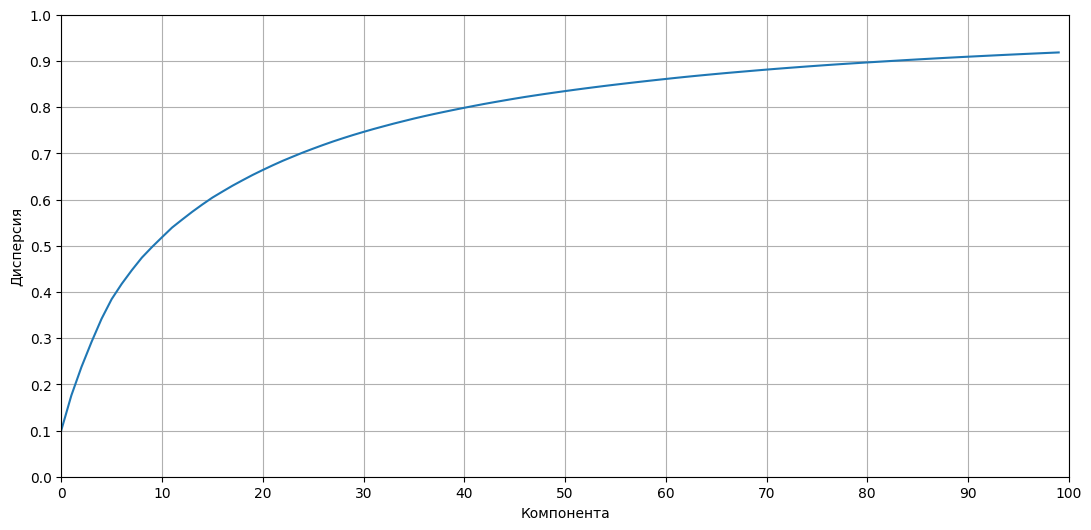

In [ ]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_comp = len(cum_var)                    

plt.figure(figsize=(13, 6))
plt.plot(cum_var)
plt.xlabel("Компонента")
plt.ylabel("Дисперсия")
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlim(0, n_comp)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=12))

plt.grid(True)
plt.show()

Для этого датасета мы видим, что первые 40 компонент охватывают около 80% дисперсии, 80 компонент — 90%, то, что выше изменяется незначительно

В качестве метрик качества кластеризации будем использовать:
Adjusted Rand Index (ARI)
Adjusted Mutual Information (AMI)
Fowlkes-Mallows Index (FMI)

In [50]:
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.utils import check_array, check_random_state
from sklearn.utils.validation import check_is_fitted

class MyKMeans(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=10, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.tol = tol
        self.random_state = random_state

    def fit(self, X, y=None):
        X = check_array(X)
        random_state = check_random_state(self.random_state)

        self.cluster_centers_ = X[random_state.choice(len(X), size=self.n_clusters, replace=False)]

        while True:
            distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
            labels = np.argmin(distances, axis=1)
            new_centers = np.array([np.mean(X[labels == k], axis=0) for k in range(self.n_clusters)])

            if np.max(np.linalg.norm(new_centers - self.cluster_centers_, axis=1)) < self.tol:
                break

            self.cluster_centers_ = new_centers

        self.labels_ = labels

        return self

    def predict(self, X):
        check_is_fitted(self)
        X = check_array(X)
        distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
        labels = np.argmin(distances, axis=1)

        return labels

In [51]:
%%time
xs = [data, *(PCA(n_components=i).fit_transform(data) for i in [70, 150, 250, 400])]

CPU times: user 8.96 s, sys: 100 ms, total: 9.06 s
Wall time: 862 ms


In [52]:
import itertools
import numpy as np
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, fowlkes_mallows_score
from sklearn.base import clone
import time

def train(estimator, params):
    results = []

    param_combinations = list(itertools.product(*params.values()))

    for x in xs:
        best_ari = -np.inf
        best_ami = -np.inf
        best_fmi = -np.inf
        best_params_ari = None
        best_params_ami = None
        best_params_fmi = None

        for param_values in param_combinations:
            param_dict = dict(zip(params.keys(), param_values))
            estimator_instance = clone(estimator).set_params(**param_dict)

            start_time = time.perf_counter()
            pred = estimator_instance.fit_predict(x)
            pred_time = time.perf_counter() - start_time

            ari = adjusted_rand_score(labels, pred)
            ami = adjusted_mutual_info_score(labels, pred)
            fmi = fowlkes_mallows_score(labels, pred)

            if ari > best_ari:
                best_ari = ari
                best_params_ari = param_dict

            if ami > best_ami:
                best_ami = ami
                best_params_ami = param_dict

            if fmi > best_fmi:
                best_fmi = fmi
                best_params_fmi = param_dict

        res = {
            "Cluster": estimator.__class__.__name__,
            "Dimensions": x.shape[1],
            "Mean fit predict time, s": (pred_time),
            "Best ARI": best_ari,
            "Best AMI": best_ami,
            "Best FMI": best_fmi
        }

        print(f"Best params for {x.shape[1]} dimensions:")
        print(f"By ARI: {best_params_ari}")
        print(f"By AMI: {best_params_ami}")
        print(f"By FMI: {best_params_fmi}")

        print(res)
        results.append(res)

    return results

In [53]:
%%time
labels = true_labels
my_kmeans = train(
    MyKMeans(n_clusters=10, random_state=0),
    params={}
)

Best params for 784 dimensions:
By ARI: {}
By AMI: {}
By FMI: {}
{'Cluster': 'MyKMeans', 'Dimensions': 784, 'Mean fit predict time, s': 45.70884630100045, 'Best ARI': 0.38927401842721143, 'Best AMI': 0.5045229098836235, 'Best FMI': 0.45127350445419406}
Best params for 70 dimensions:
By ARI: {}
By AMI: {}
By FMI: {}
{'Cluster': 'MyKMeans', 'Dimensions': 70, 'Mean fit predict time, s': 0.9984177410005941, 'Best ARI': 0.34345221257804365, 'Best AMI': 0.4772286541329463, 'Best FMI': 0.41005171087007386}
Best params for 150 dimensions:
By ARI: {}
By AMI: {}
By FMI: {}
{'Cluster': 'MyKMeans', 'Dimensions': 150, 'Mean fit predict time, s': 2.8681645690012374, 'Best ARI': 0.38928478573407244, 'Best AMI': 0.5045032630508598, 'Best FMI': 0.4513071425109308}
Best params for 250 dimensions:
By ARI: {}
By AMI: {}
By FMI: {}
{'Cluster': 'MyKMeans', 'Dimensions': 250, 'Mean fit predict time, s': 5.097299135006324, 'Best ARI': 0.38958212902050526, 'Best AMI': 0.5046964809436045, 'Best FMI': 0.45151757

In [54]:
%%time
from sklearn.cluster import KMeans

kmeans = train(
    KMeans(n_clusters=10, n_init='auto', random_state=0),
    params={"algorithm": ["lloyd", "elkan"]}
)

Best params for 784 dimensions:
By ARI: {'algorithm': 'lloyd'}
By AMI: {'algorithm': 'lloyd'}
By FMI: {'algorithm': 'lloyd'}
{'Cluster': 'KMeans', 'Dimensions': 784, 'Mean fit predict time, s': 0.5302326960008941, 'Best ARI': 0.37710376839240195, 'Best AMI': 0.4988382912651836, 'Best FMI': 0.44060519388293956}
Best params for 70 dimensions:
By ARI: {'algorithm': 'lloyd'}
By AMI: {'algorithm': 'lloyd'}
By FMI: {'algorithm': 'lloyd'}
{'Cluster': 'KMeans', 'Dimensions': 70, 'Mean fit predict time, s': 0.17713274600100704, 'Best ARI': 0.3815062228666266, 'Best AMI': 0.5007441065575473, 'Best FMI': 0.444532131726211}
Best params for 150 dimensions:
By ARI: {'algorithm': 'lloyd'}
By AMI: {'algorithm': 'lloyd'}
By FMI: {'algorithm': 'lloyd'}
{'Cluster': 'KMeans', 'Dimensions': 150, 'Mean fit predict time, s': 0.2233882000000449, 'Best ARI': 0.39576931451279435, 'Best AMI': 0.5065909382395803, 'Best FMI': 0.46001095327099656}
Best params for 250 dimensions:
By ARI: {'algorithm': 'lloyd'}
By AM

In [55]:
%%time
from sklearn.cluster import DBSCAN

dbscan = train(
    DBSCAN(n_jobs=4),
    params={
        "eps": [0.5, 0.75, 1, 2, 5],
        "min_samples": [2, 3, 5, 10, 20],
    }
)

Best params for 784 dimensions:
By ARI: {'eps': 0.5, 'min_samples': 2}
By AMI: {'eps': 0.5, 'min_samples': 2}
By FMI: {'eps': 0.5, 'min_samples': 2}
{'Cluster': 'DBSCAN', 'Dimensions': 784, 'Mean fit predict time, s': 1.9457566429991857, 'Best ARI': 0.0, 'Best AMI': 0.0, 'Best FMI': 0.31663929958961895}
Best params for 70 dimensions:
By ARI: {'eps': 0.5, 'min_samples': 2}
By AMI: {'eps': 0.5, 'min_samples': 2}
By FMI: {'eps': 0.5, 'min_samples': 2}
{'Cluster': 'DBSCAN', 'Dimensions': 70, 'Mean fit predict time, s': 0.10208124900236726, 'Best ARI': 0.0, 'Best AMI': 0.0, 'Best FMI': 0.31663929958961895}
Best params for 150 dimensions:
By ARI: {'eps': 0.5, 'min_samples': 2}
By AMI: {'eps': 0.5, 'min_samples': 2}
By FMI: {'eps': 0.5, 'min_samples': 2}
{'Cluster': 'DBSCAN', 'Dimensions': 150, 'Mean fit predict time, s': 0.1779360170039581, 'Best ARI': 0.0, 'Best AMI': 0.0, 'Best FMI': 0.31663929958961895}
Best params for 250 dimensions:
By ARI: {'eps': 0.5, 'min_samples': 2}
By AMI: {'eps':

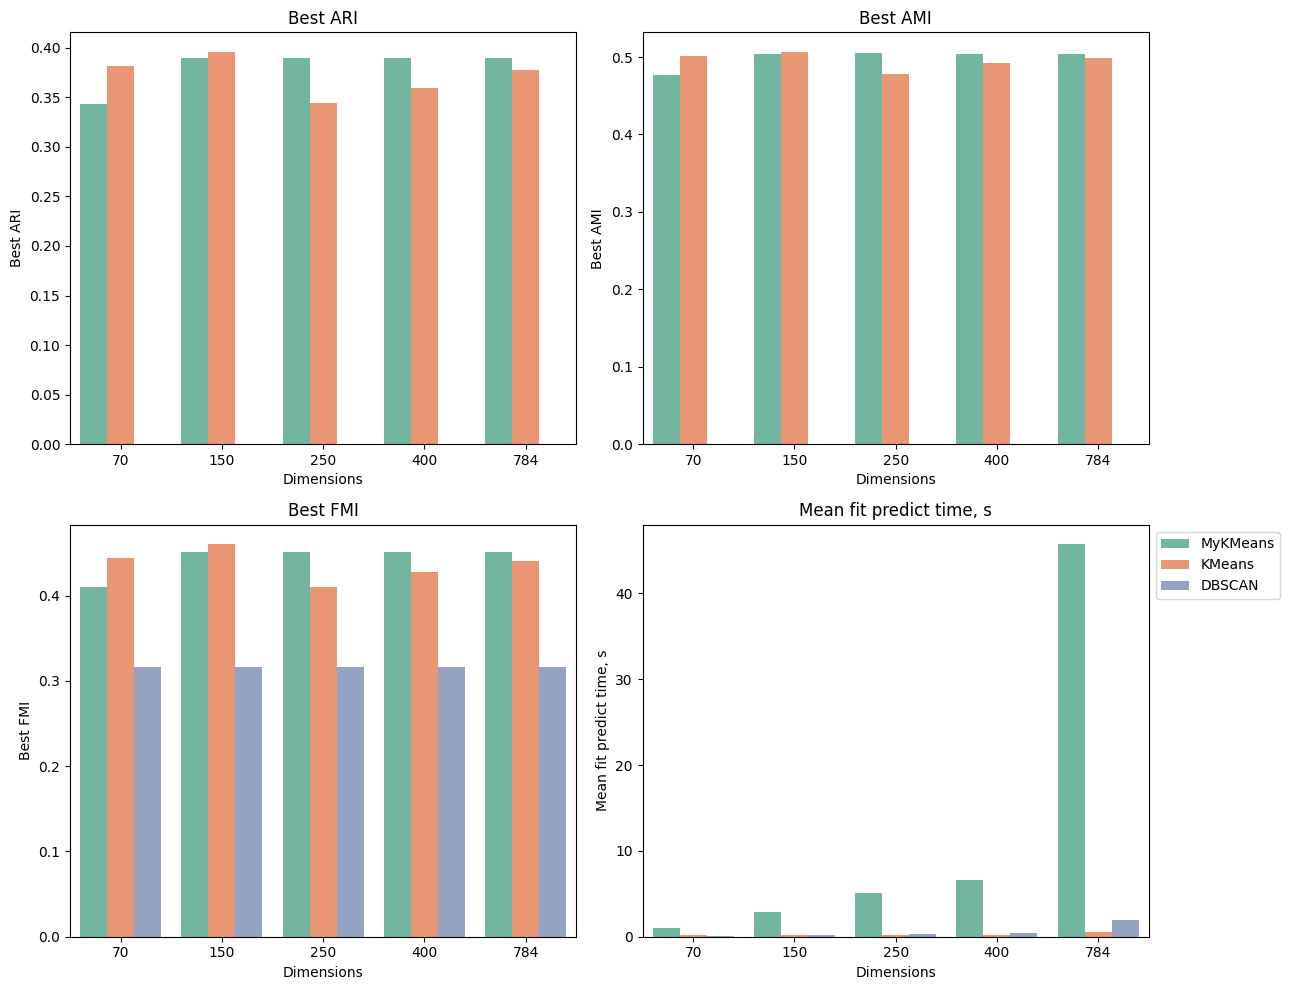

In [56]:
results = pd.DataFrame(my_kmeans + kmeans + dbscan)
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(13, 10))
palette = "Set2"

for metric, ax in zip(["Best ARI", "Best AMI", "Best FMI", "Mean fit predict time, s"], axs.flatten()):
    sns.barplot(data=results, x="Dimensions", y=metric, hue="Cluster", ax=ax, palette=palette)

    if metric == "Mean fit predict time, s":
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    else:
        ax.get_legend().remove()

    ax.set_title(metric)

fig.tight_layout()

plt.show()

KMeans от sklearn обучается быстрее чем DBSCAN\
На данных из этого датасета хуже всего себя показала модель DBSCAN